# Tests for Means, Variances and Proportions

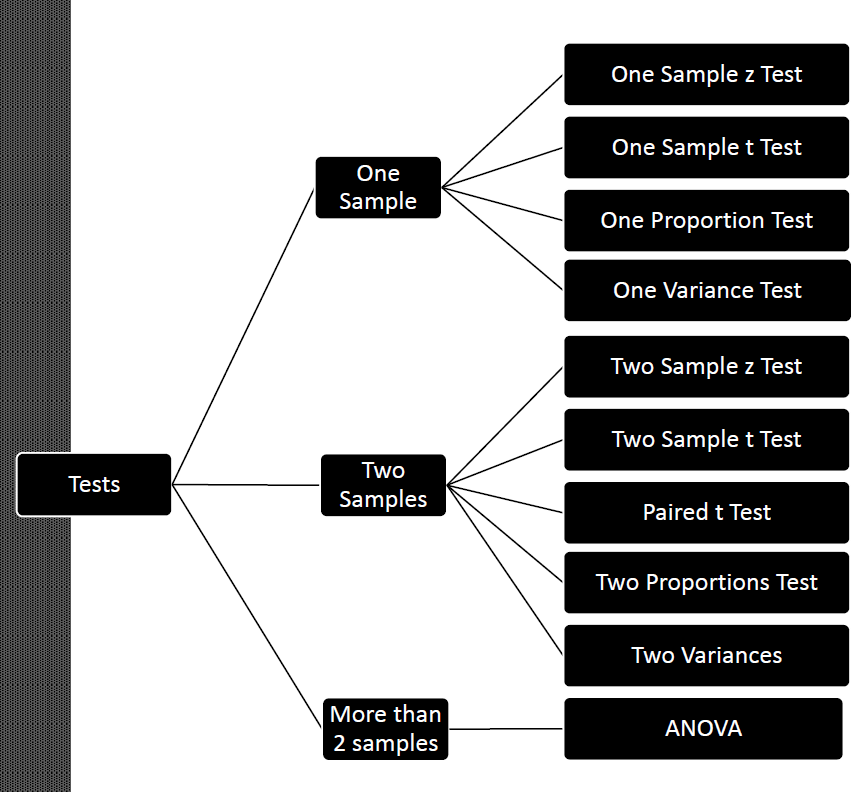

# ---------------------------------------------------------------------------------------------------------

## One Sample Z Test:

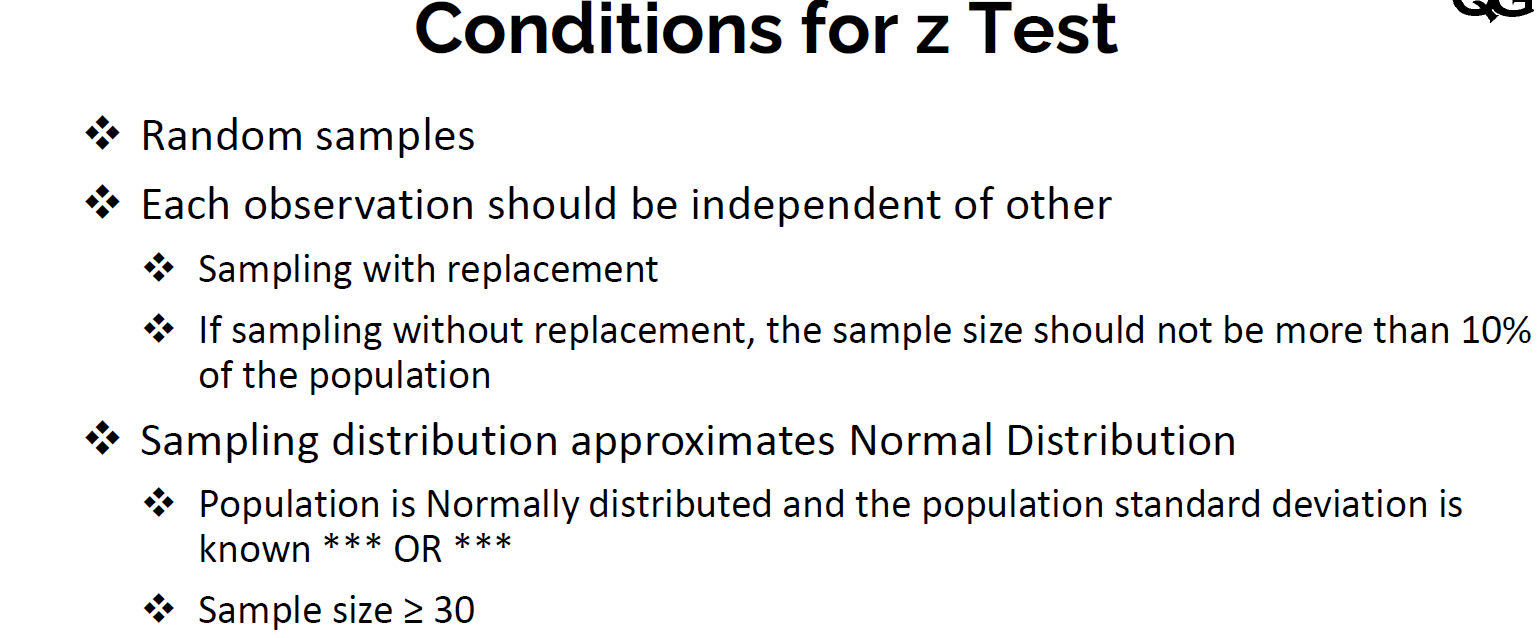

### Example 1:

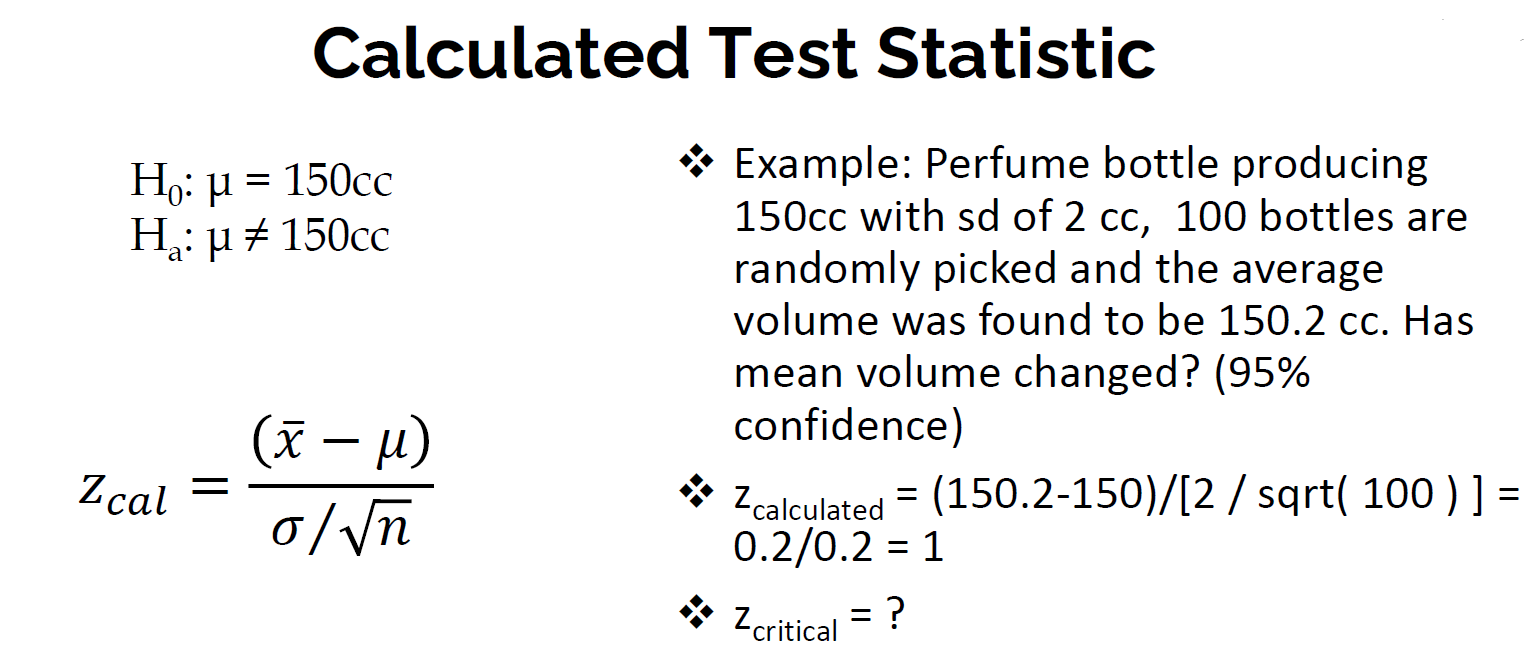

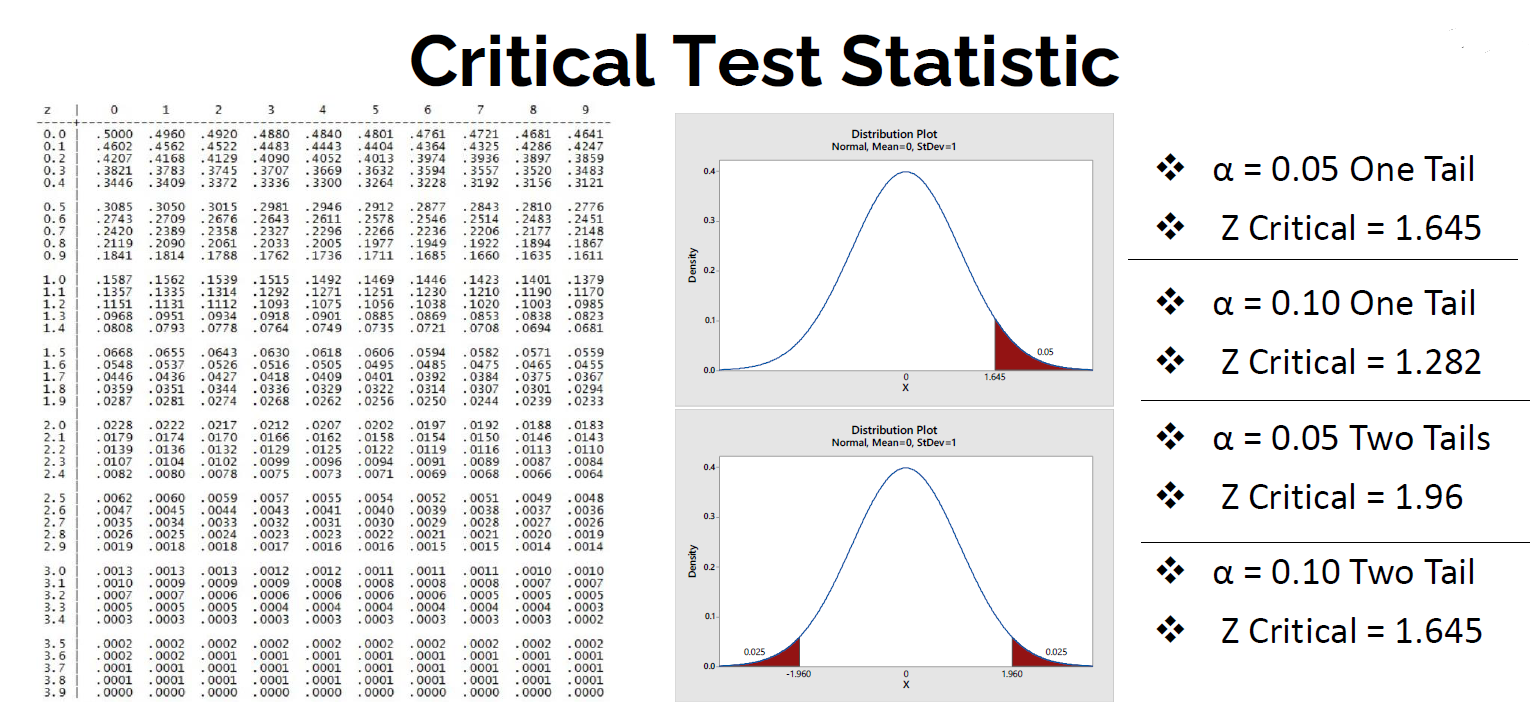

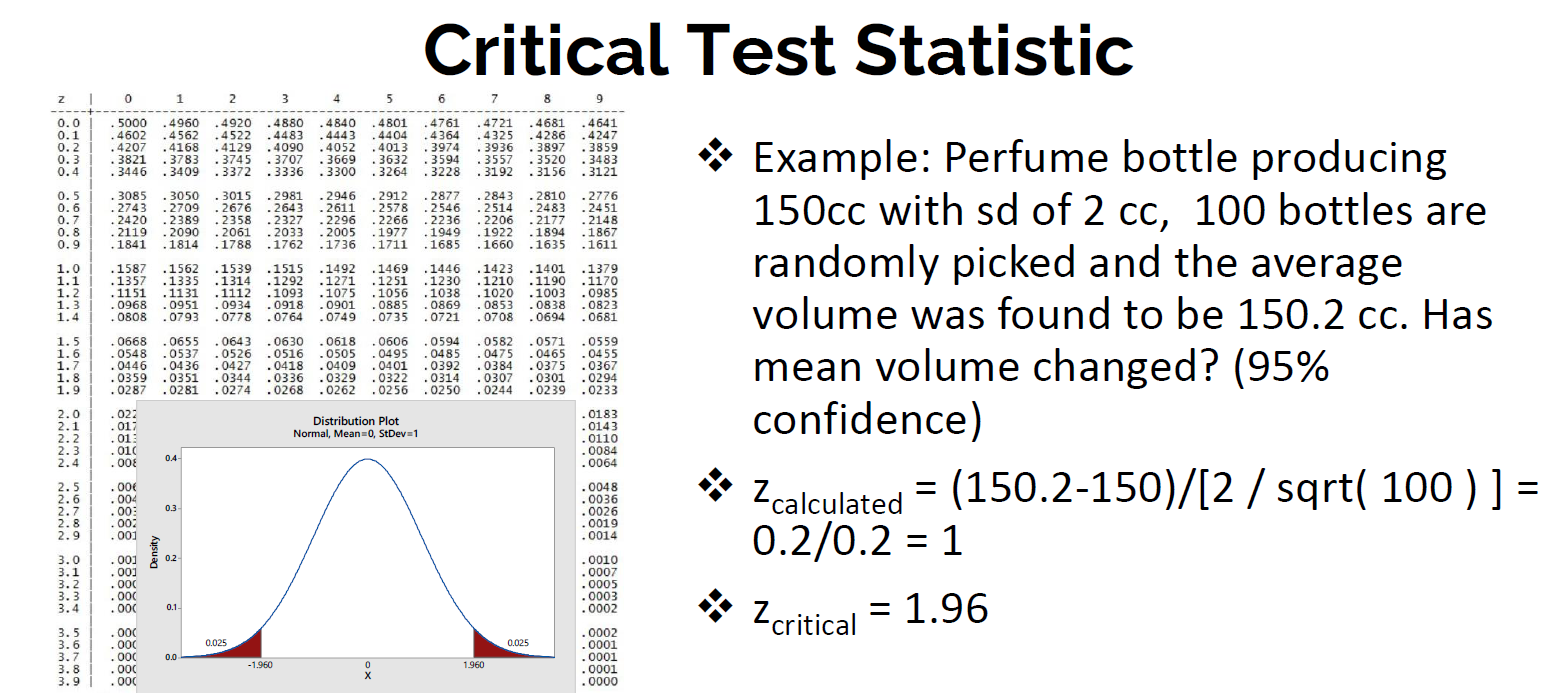

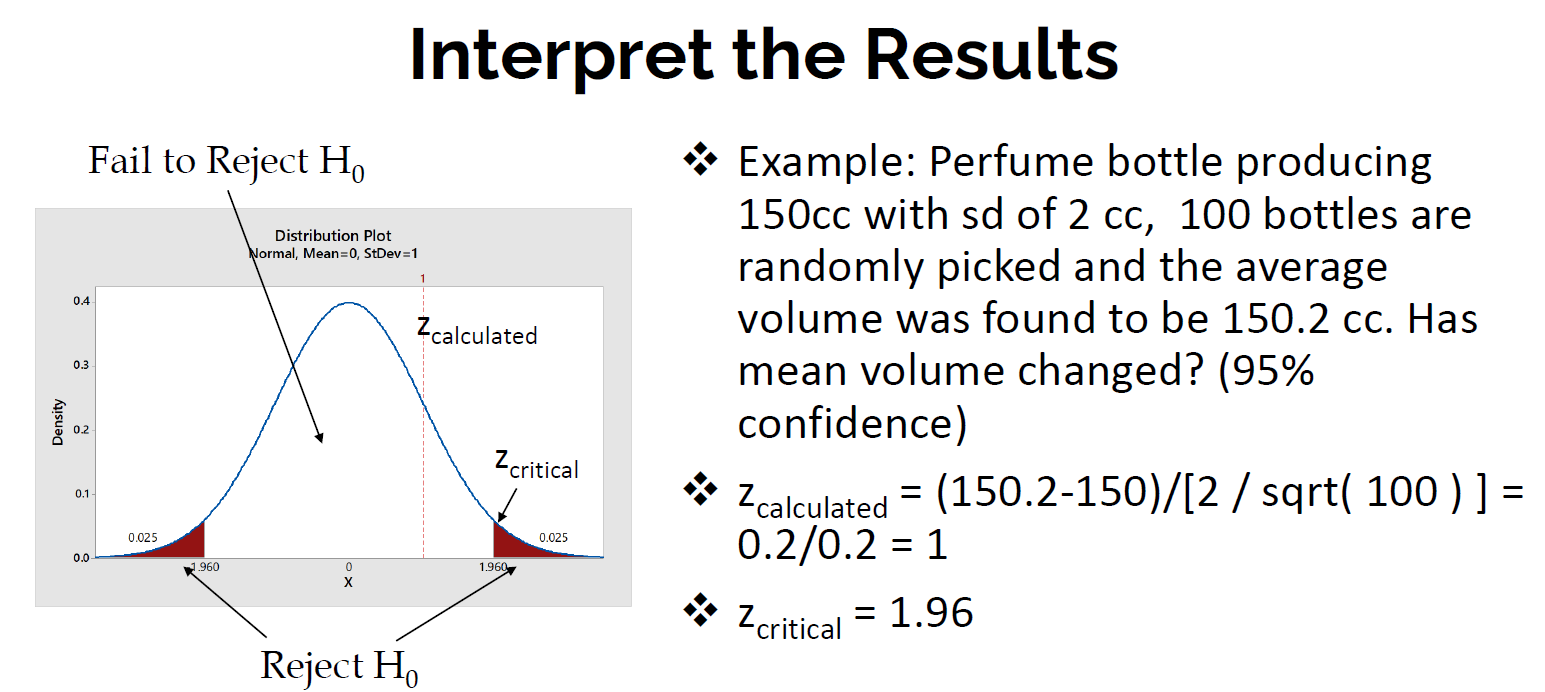

### Example 2:

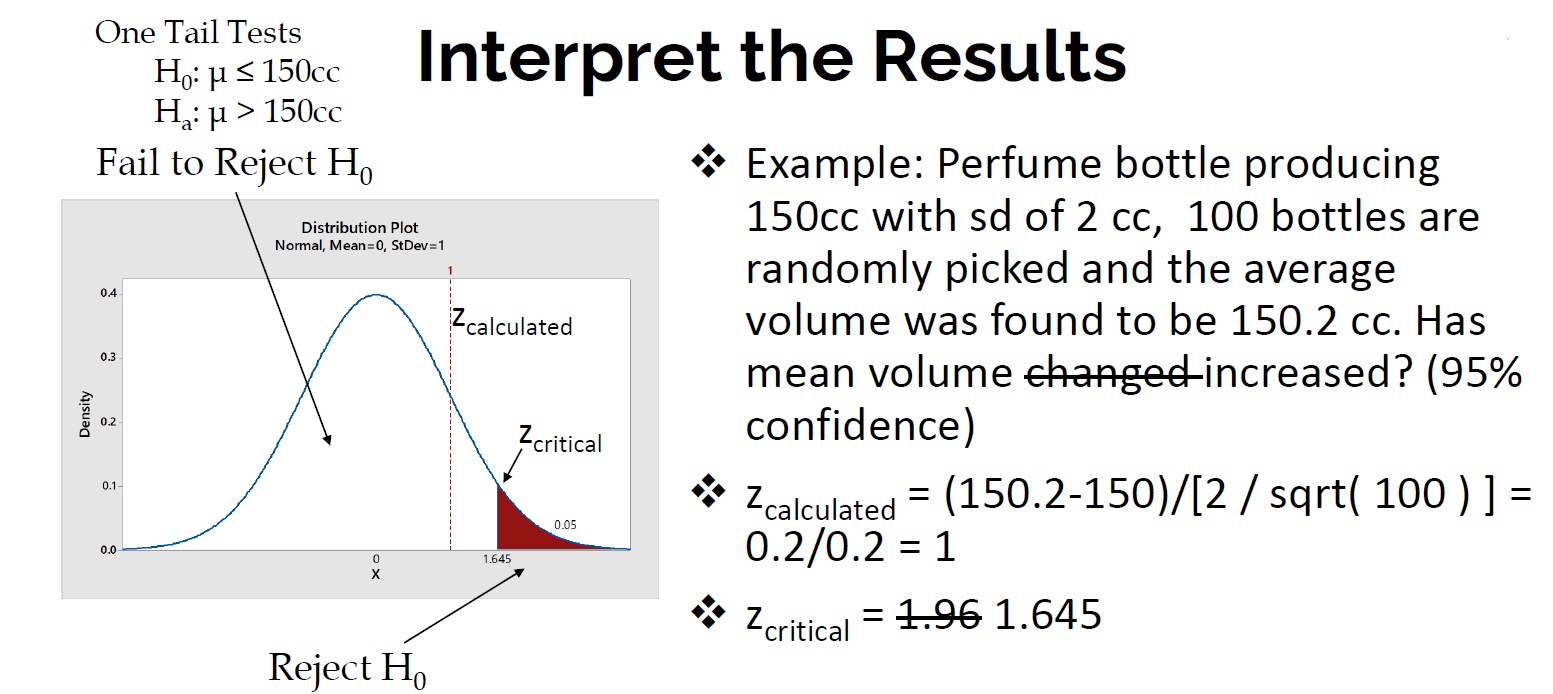

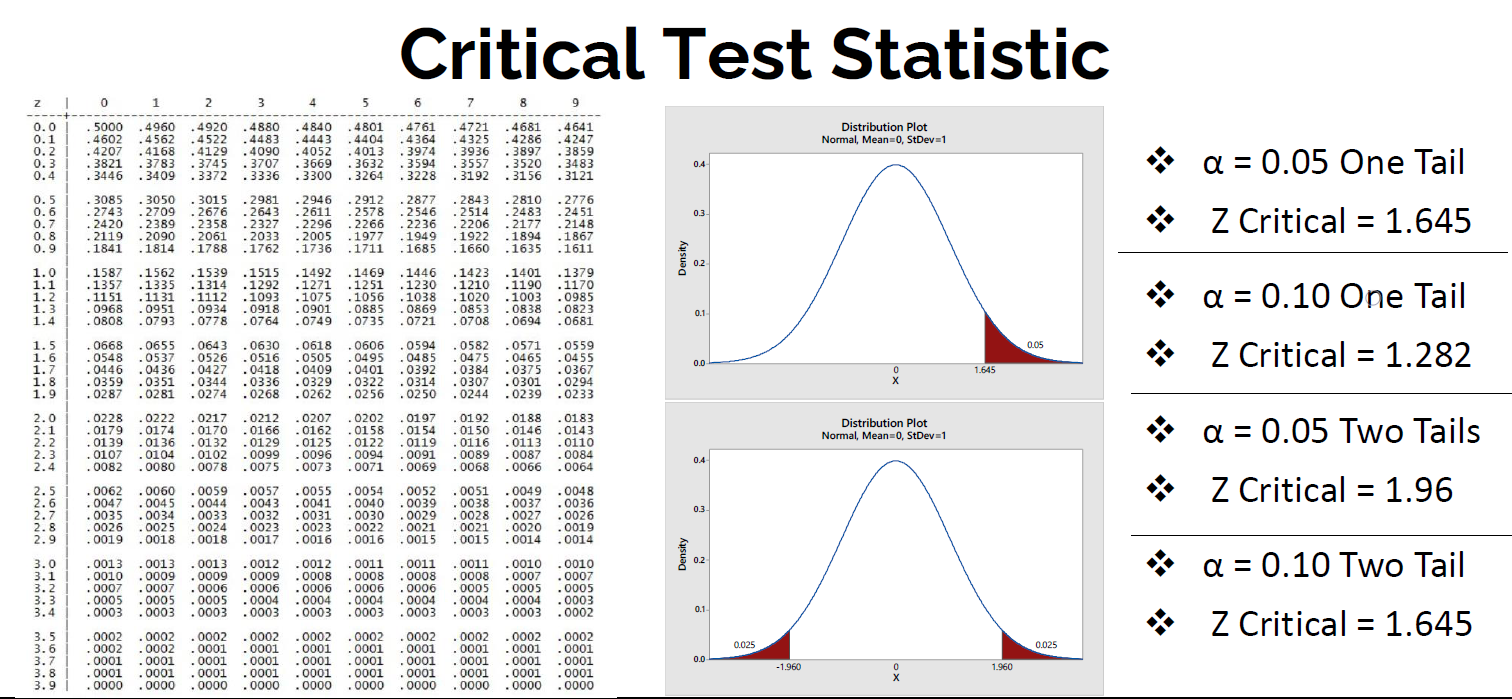

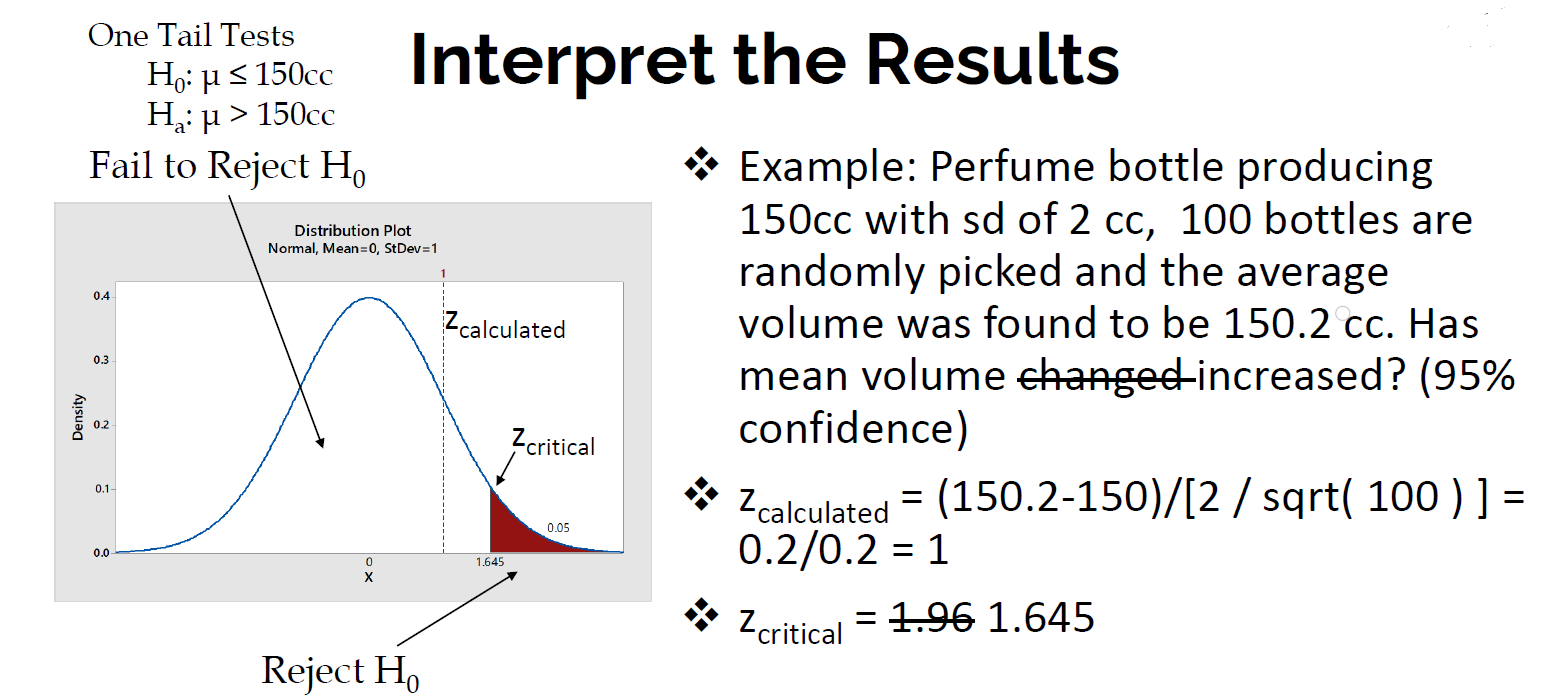

### One Sample Z Test Using Python:

# ---------------------------------------------------------------------------------------------------------

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_1samp # For 1 Sample t-Test.
from scipy.stats import binomtest # For 1 Sample Proportion Test.
from scipy.stats import chi2 # Foe 1 Sample Variance Test.
from statsmodels.stats import weightstats

Note: Scipy Doesn't Have Z-Test.

In [2]:
df = pd.read_csv('Machine1.csv')

In [3]:
df.head()

,Machine 1
0,152.63
1,152.94
2,151.29
3,153.44
4,148.58


In [4]:
df.shape

(100, 1)

In [6]:
df.describe()

,Machine 1
count,100.000000
mean,150.203100
std,2.018812
min,145.550000
25%,148.717500
50%,150.285000
75%,151.502500
max,154.550000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Machine 1  100 non-null    float64
dtypes: float64(1)
memory usage: 932.0 bytes


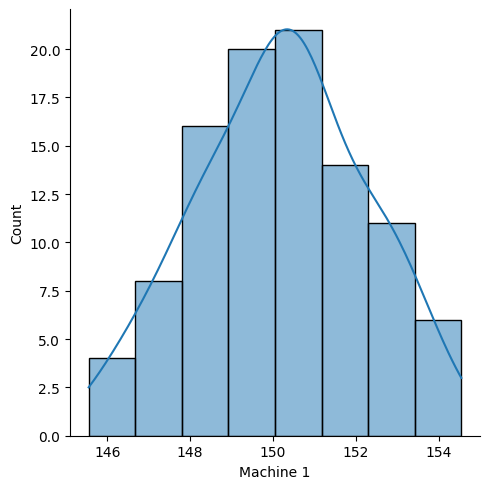

In [8]:
sns.displot(data= df, x= 'Machine 1', kde= True)
plt.show()

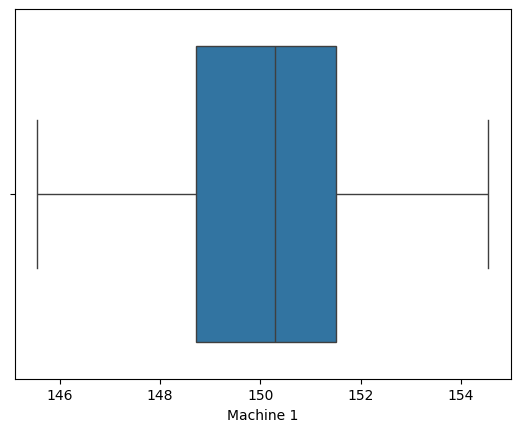

In [9]:
sns.boxplot(data= df, x= 'Machine 1')
plt.show()

##### Example: Perfume bottle producing 150cc with sd of 2 cc, 100 bottles are randomly picked and the average volume was found to be 150.2 cc. Has mean volume changed? (95% confidence)

H0 : μ = 150cc

Ha : μ ≠ 150cc

In [10]:
weightstats.ztest(x1= df['Machine 1'], value= 150, alternative= 'two-sided')

(1.0060370247722599, 0.3143977600779597)

These are Calculated Z-Value and p-Value.

In [11]:
z_calculated, p_value = weightstats.ztest(x1= df['Machine 1'], 
                                          value= 150, 
                                          alternative= 'two-sided')

In [12]:
print(f'Calculated Test Statistic is: {z_calculated}')
print(f'p_Value is: {p_value}')

Calculated Test Statistic is: 1.0060370247722599
p_Value is: 0.3143977600779597


alpha is 0.05.

p_value > alpha

**We Can Not Reject Null Hypothesis.**

##### Example: Perfume bottle producing 150cc with sd of 2 cc, 100 bottles are randomly picked and the average volume was found to be 150.2 cc. Has mean volume increased? (95% confidence)

H0 : μ ≤ 150cc

Ha : μ > 150cc

In [13]:
z_calculated, p_value = weightstats.ztest(df['Machine 1'],
                                         value= 150,
                                         alternative= 'larger')

In [14]:
print(f'Calculated Test Statistic is: {z_calculated}')
print(f'p_Value is: {p_value}')

Calculated Test Statistic is: 1.0060370247722599
p_Value is: 0.15719888003897986


alpha is 0.05.

p_value > alpha

**We Can Not Reject Null Hypothesis.**

# ---------------------------------------------------------------------------------------------------------

## One Sample t Test:

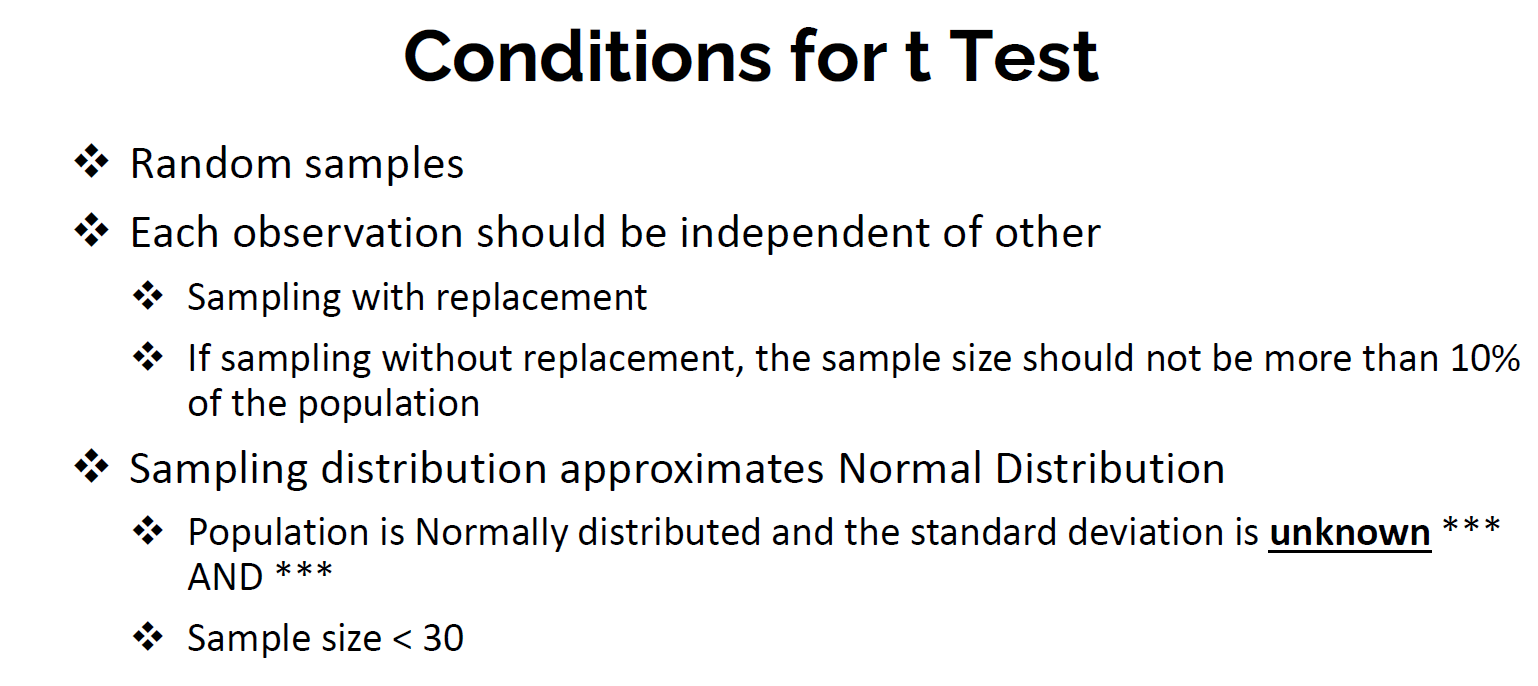

### Example:

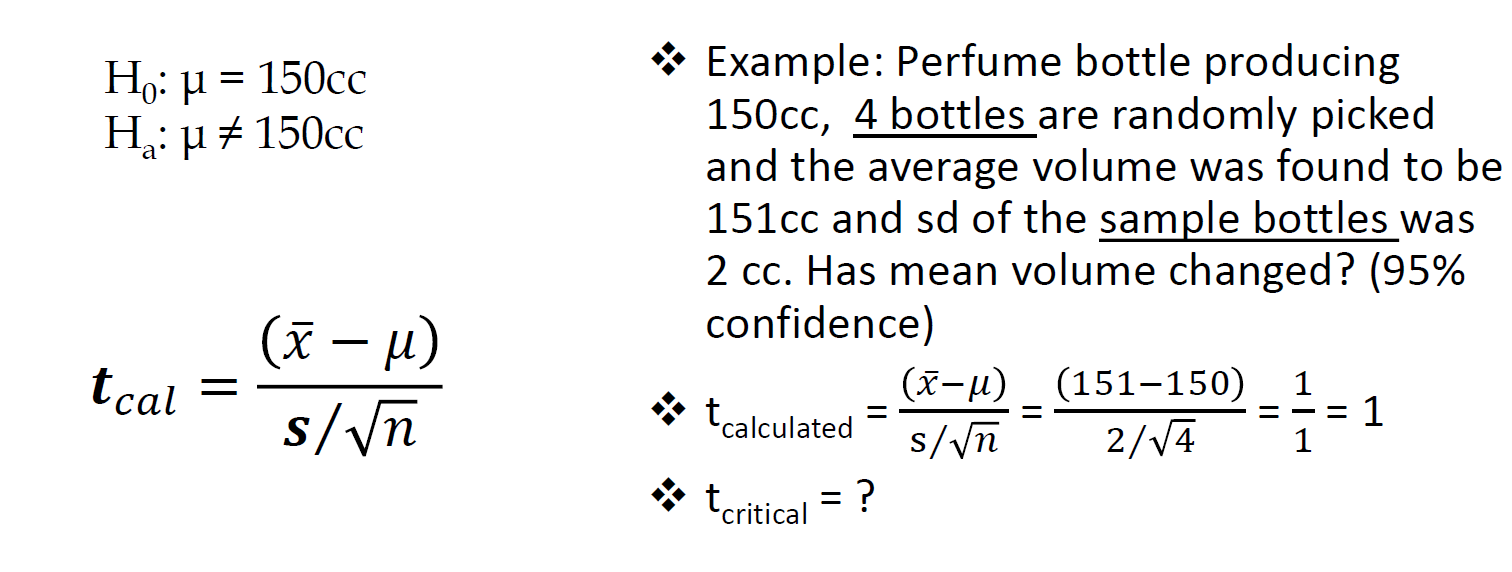

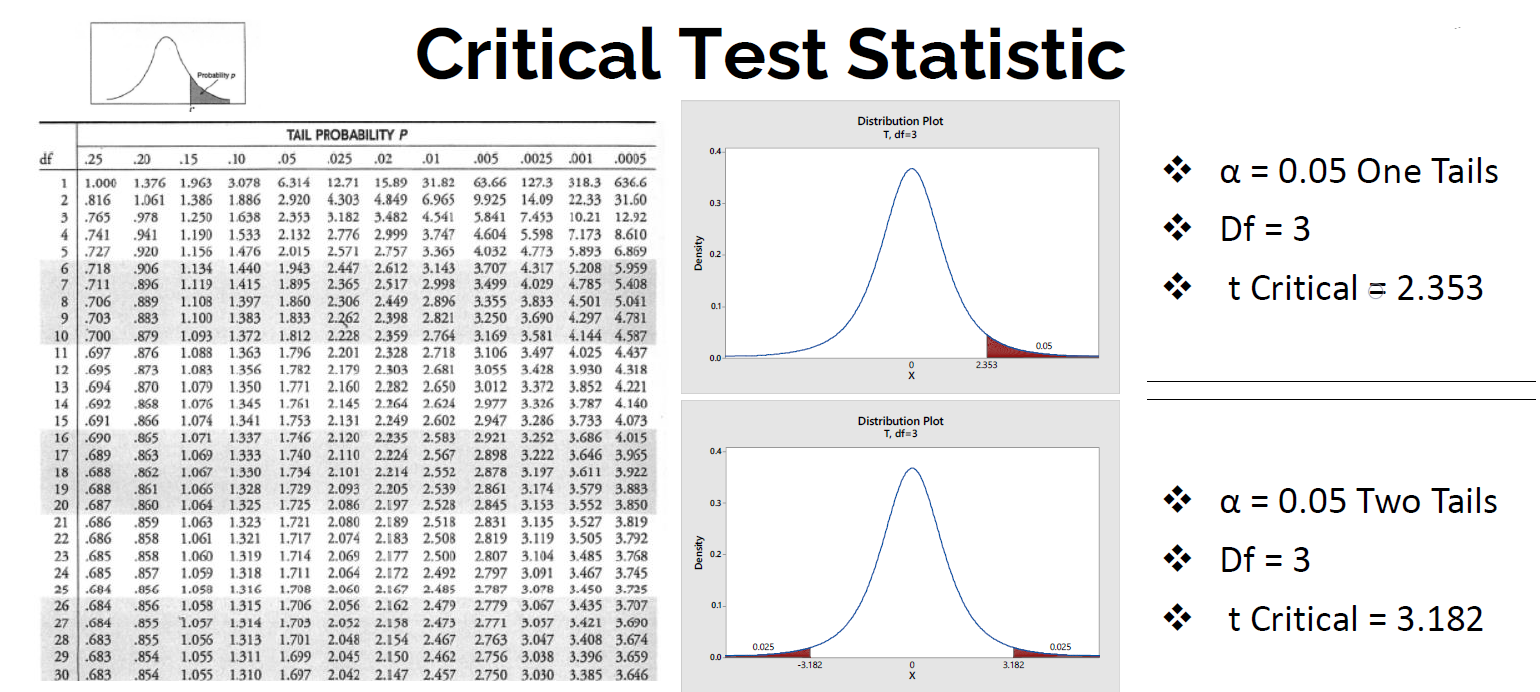

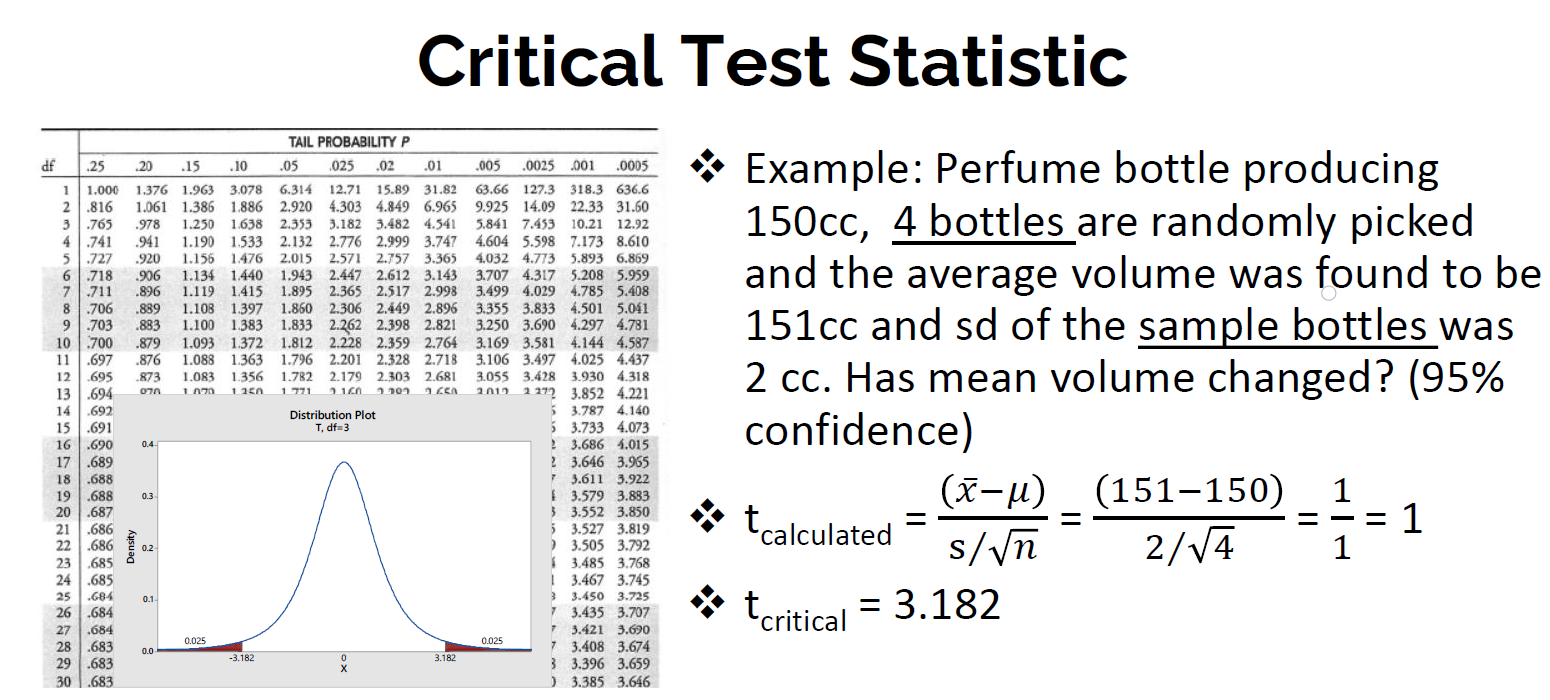

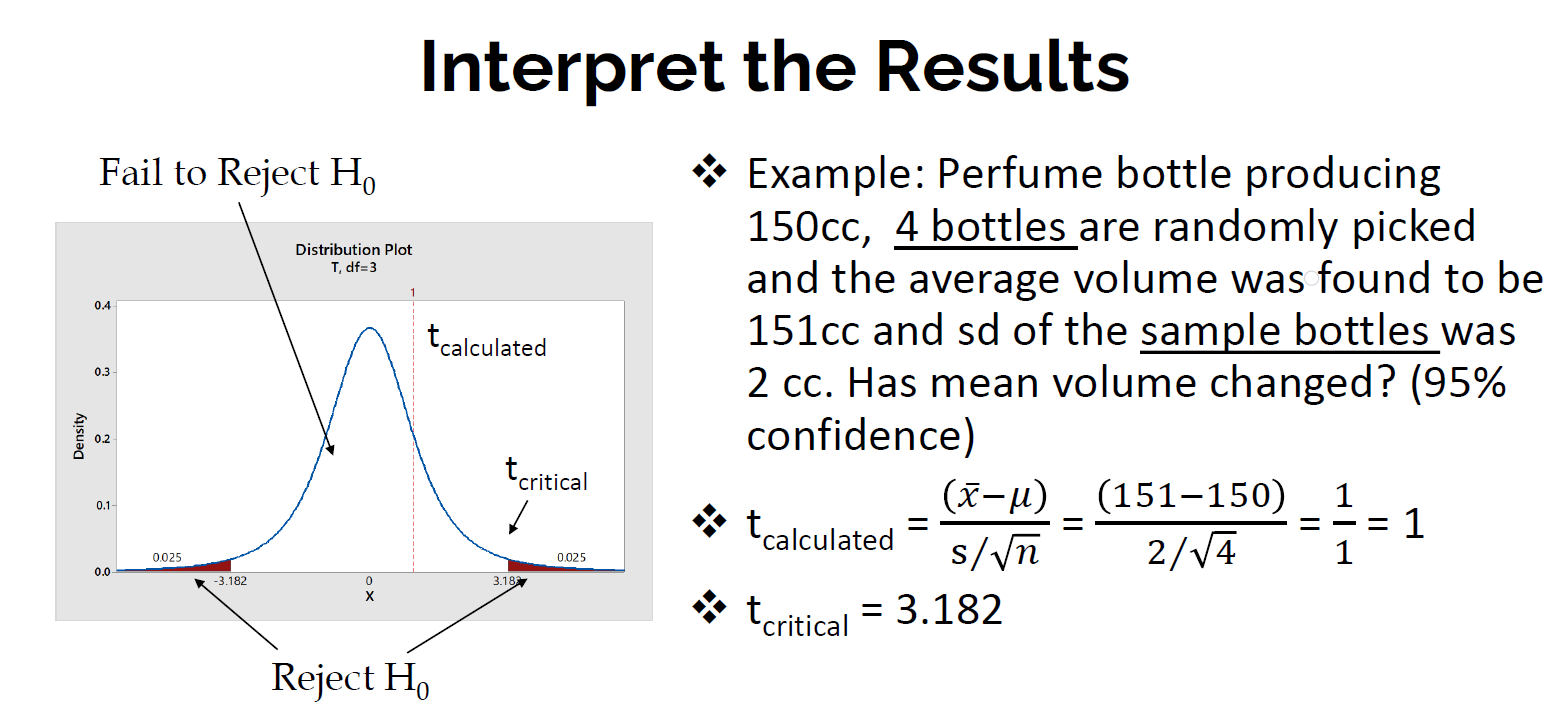

### One Sample t Test Using Python:

Example: Perfume bottle producing 150cc, 4 bottles are randomly picked and the average volume was found to be 151cc and sd of the sample bottles was 2 cc. Has mean volume changed? (95% confidence)

H0 : μ = 150cc

Ha : μ ≠ 150cc

In [16]:
volume = pd.Series([148.5, 153.4, 150.9, 151.2])

In [17]:
volume.describe()

count      4.000000
mean     151.000000
std        2.004994
min      148.500000
25%      150.300000
50%      151.050000
75%      151.750000
max      153.400000
dtype: float64

In [21]:
ttest_1samp(a= volume, popmean= 150, alternative= 'two-sided')

TtestResult(statistic=0.997509336107632, pvalue=0.3920333832606524, df=3)

alpha is 0.05.

p_value > alpha.

**We Can Not Reject Null Hypothesis.**

# ----------------------------------------------------------------------------------------------------------

## One Proportion Test:

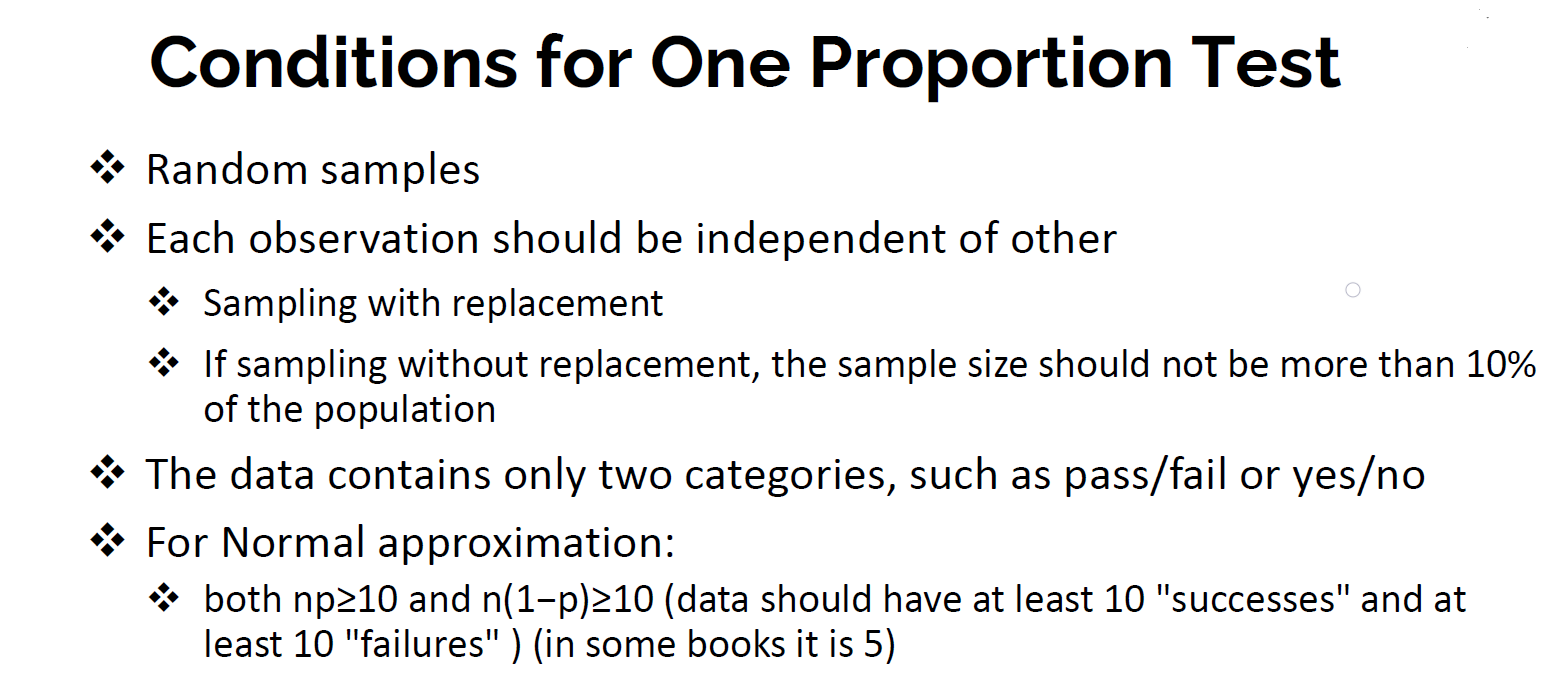

### Example 1:

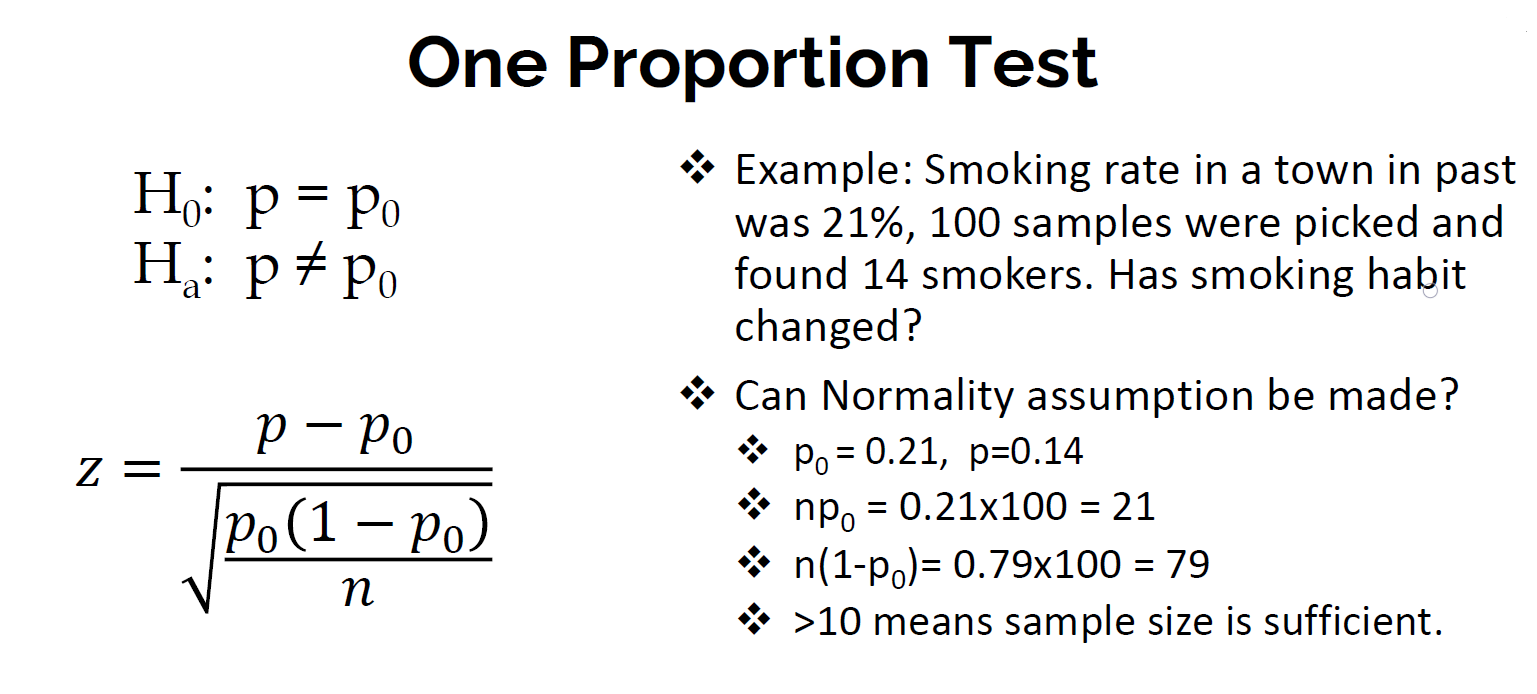

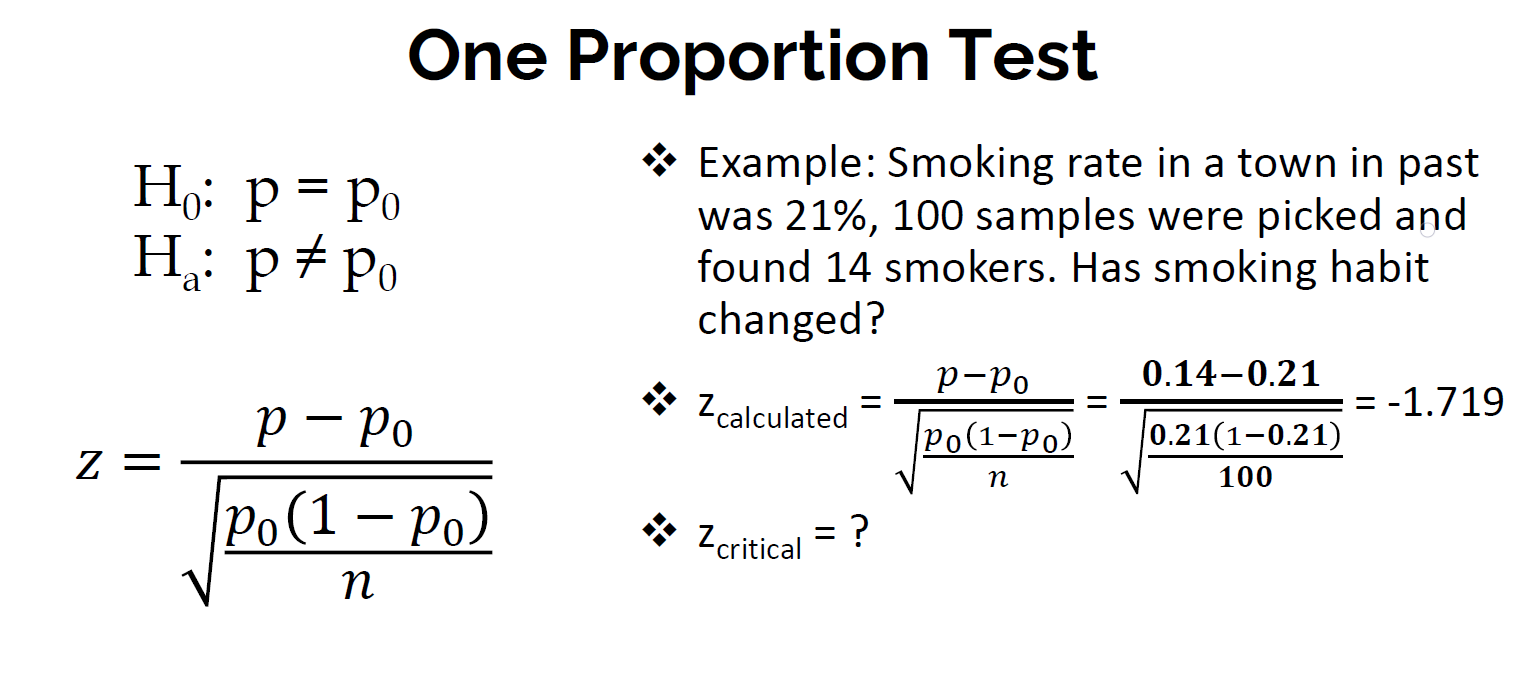

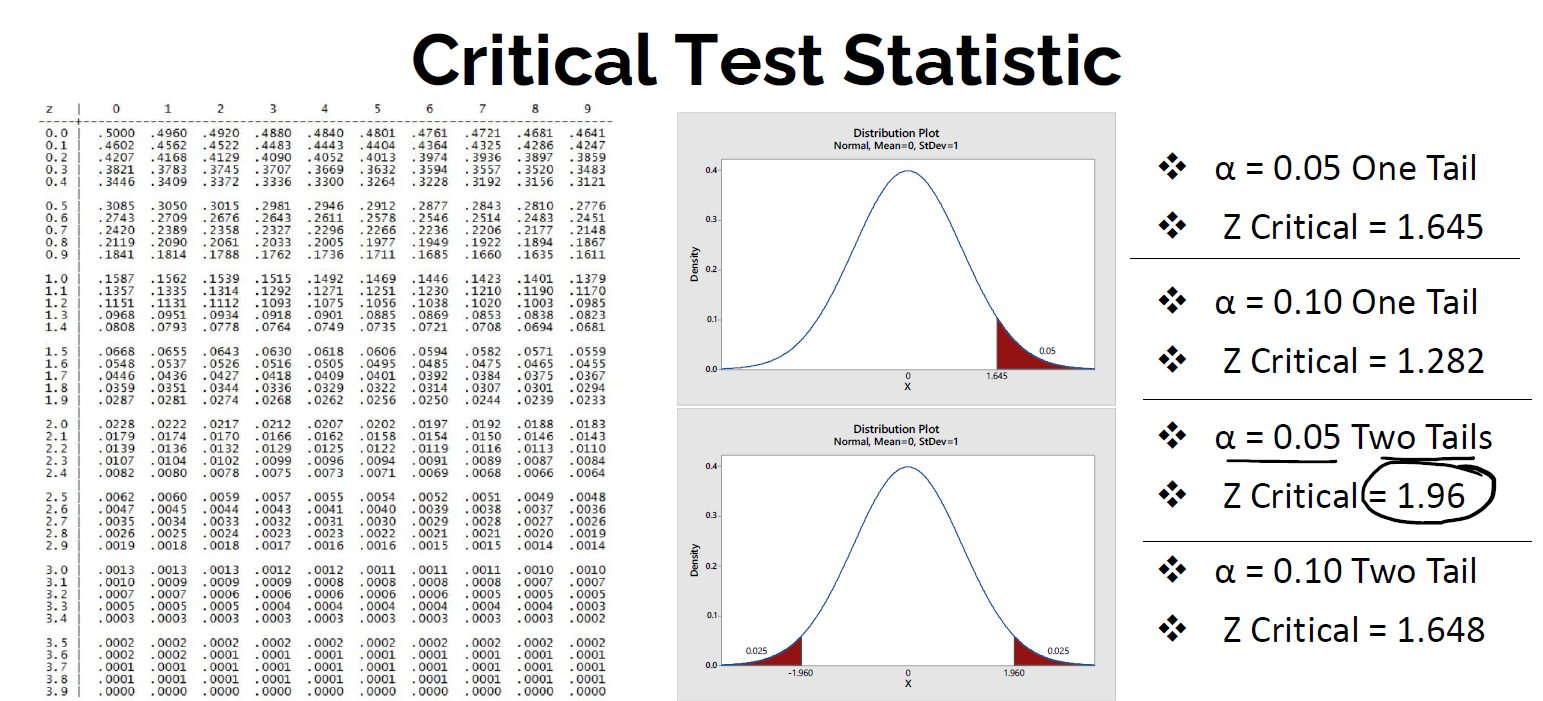

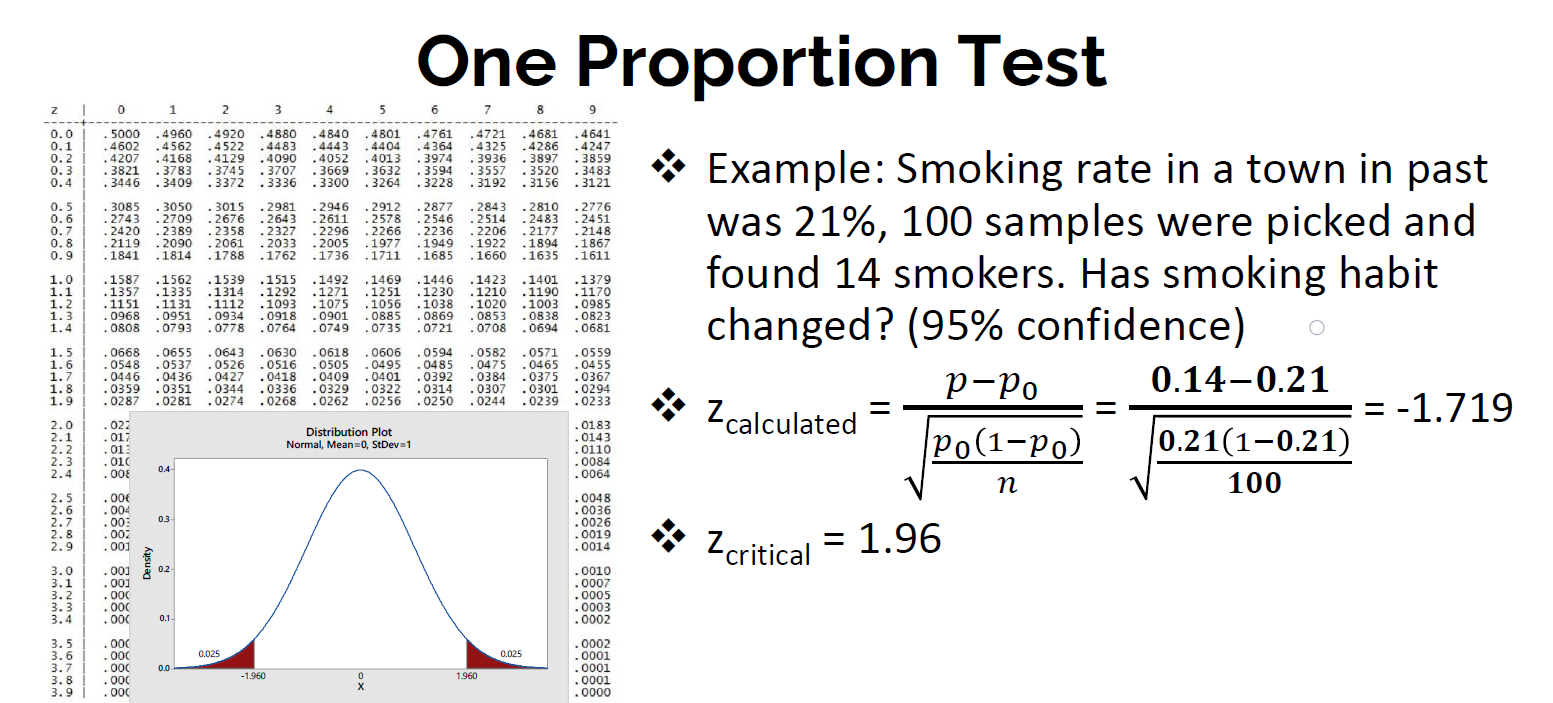

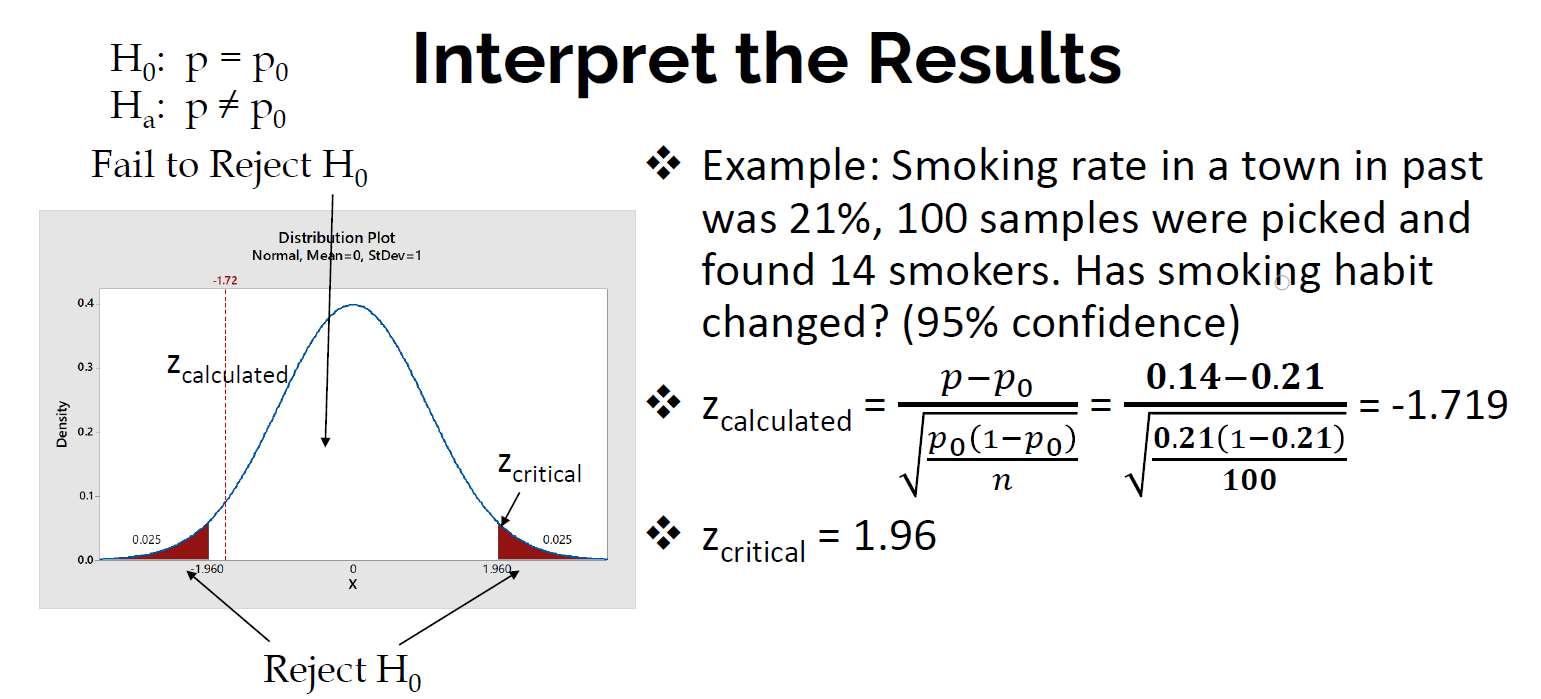

### Example 2:

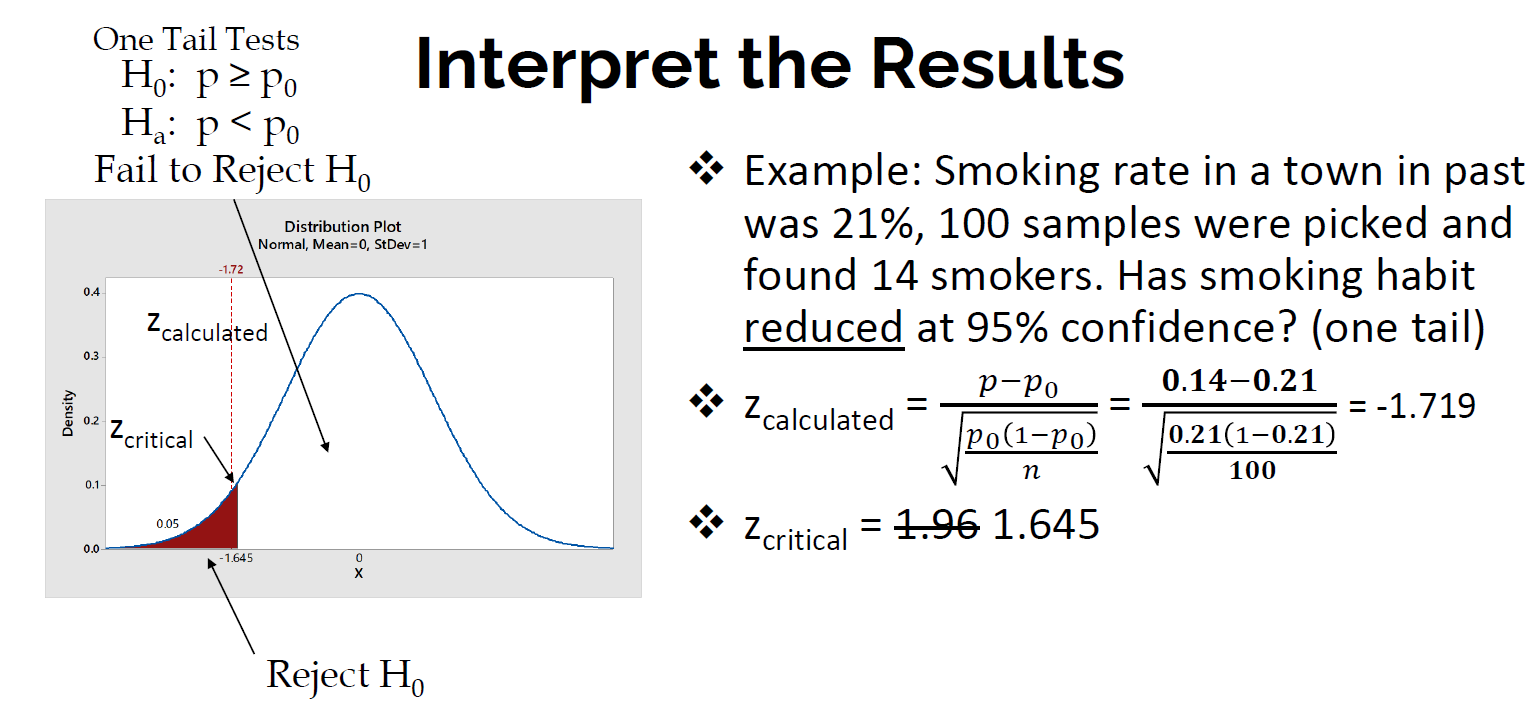

### One Proportion Test Using Python:

##### Example 1: Smoking rate in a town in past was 21%, 100 samples were picked and found 14 smokers. Has smoking habit changed? (95% confidence)

H0 : p = p0

Ha : p ≠ p0

In [22]:
df = pd.read_csv('Smokers.csv')

In [23]:
df.head()

,Name,Smokers
0,Person 1,No
1,Person 2,No
2,Person 3,No
3,Person 4,Yes
4,Person 5,No


In [24]:
df.shape

(100, 2)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Name     100 non-null    object
 1   Smokers  100 non-null    object
dtypes: object(2)
memory usage: 1.7+ KB


In [26]:
df.describe()

,Name,Smokers
count,100,100
unique,100,2
top,Person 1,No
freq,1,86


In [27]:
summary_df = df.groupby('Smokers').count()
summary_df.head()

,Name
Smokers,
No,86
Yes,14


In [28]:
summary_df = summary_df.reindex(['Yes', 'No'])
summary_df

,Name
Smokers,
Yes,14
No,86


In [31]:
binomtest(k= 14, n= 100, p= 0.21, alternative= 'two-sided')

BinomTestResult(k=14, n=100, alternative='two-sided', statistic=0.14, pvalue=0.10920815720825927)

alpha is 0.05.

p_value is 0.109 > alpha.

**We Can Not Reject Null Hypothesis**

##### Example 2: Smoking rate in a town in past was 21%, 100 samples were picked and found 14 smokers. Has smoking habit reduced? (95% confidence)

H0 : p >= p0

Ha : p < p0

In [32]:
summary_df

,Name
Smokers,
Yes,14
No,86


In [33]:
binomtest(k= 14, n= 100, p= 0.21, alternative= 'less')

BinomTestResult(k=14, n=100, alternative='less', statistic=0.14, pvalue=0.05042460221552124)

alpha ia 0.05.

p_value is 0.05 !< alpha.

**We Can Reject The Null Hypothesis**

# ----------------------------------------------------------------------------------------------------------

## One Variance Test:

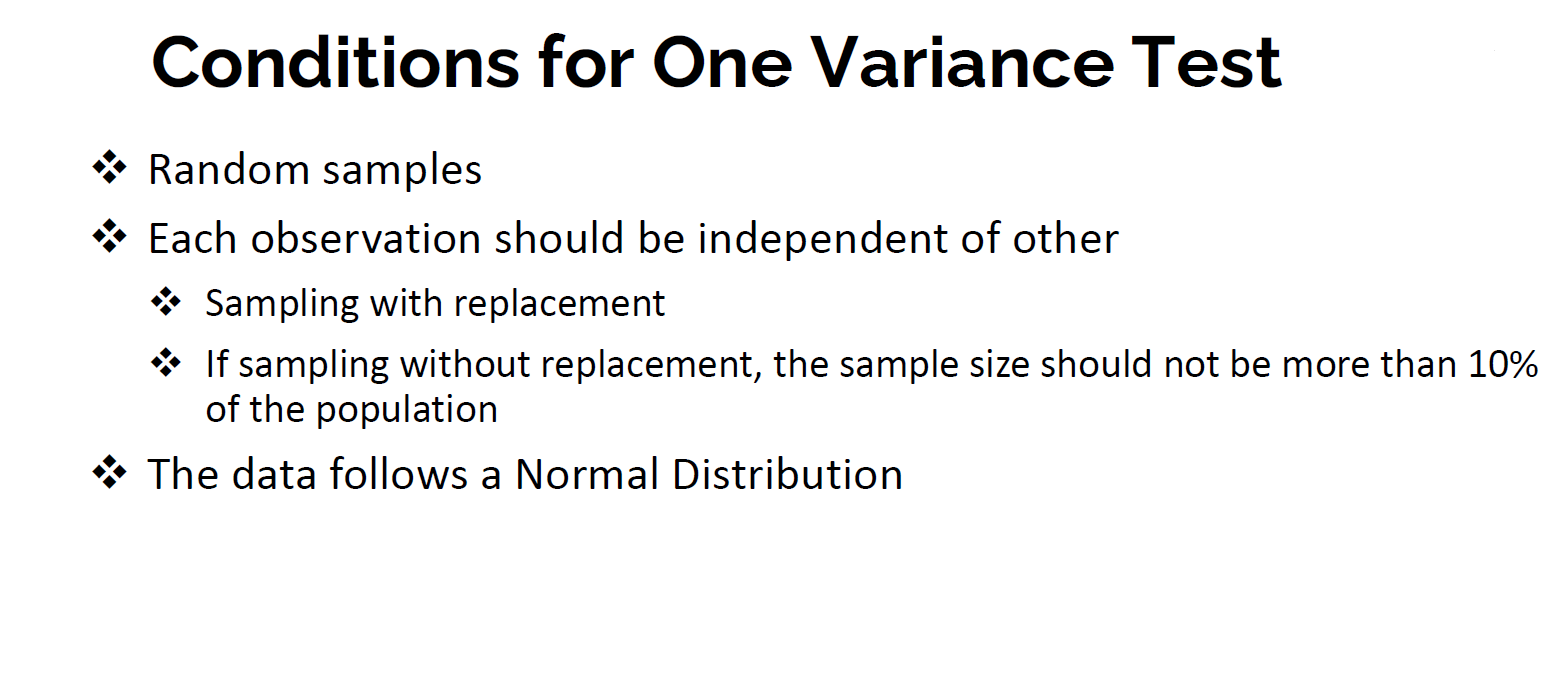

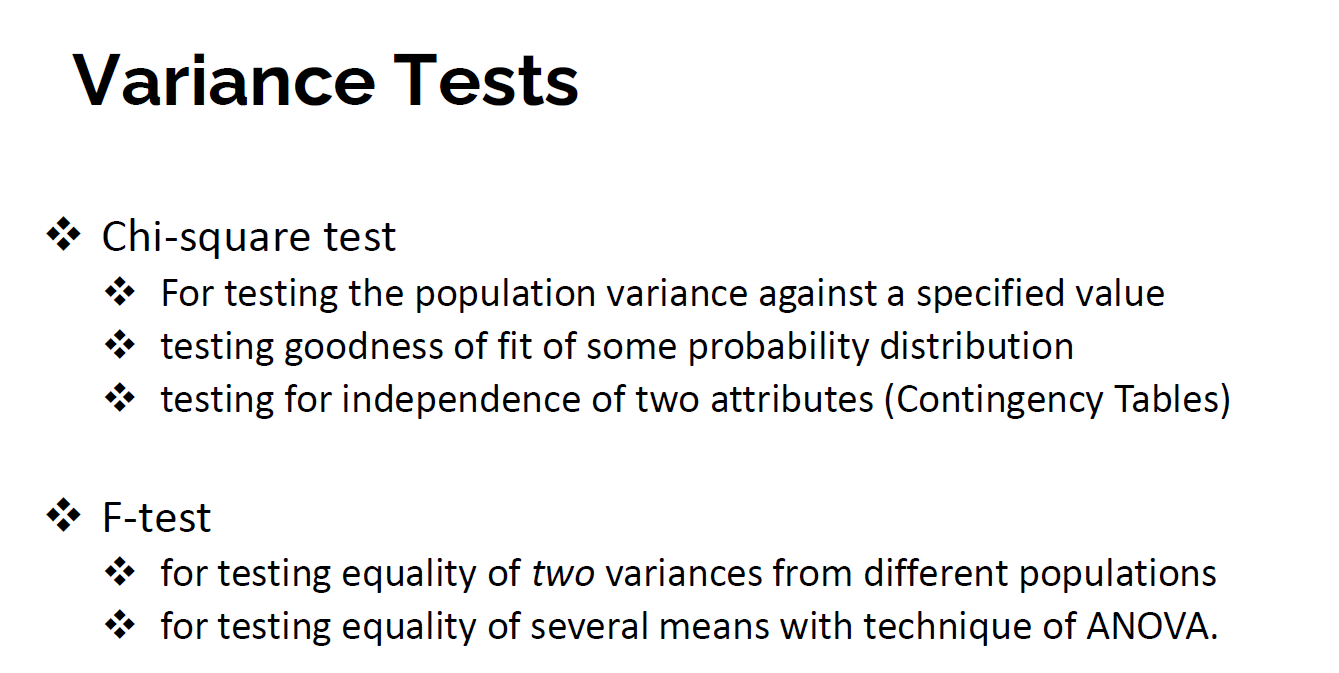

### Example 1:

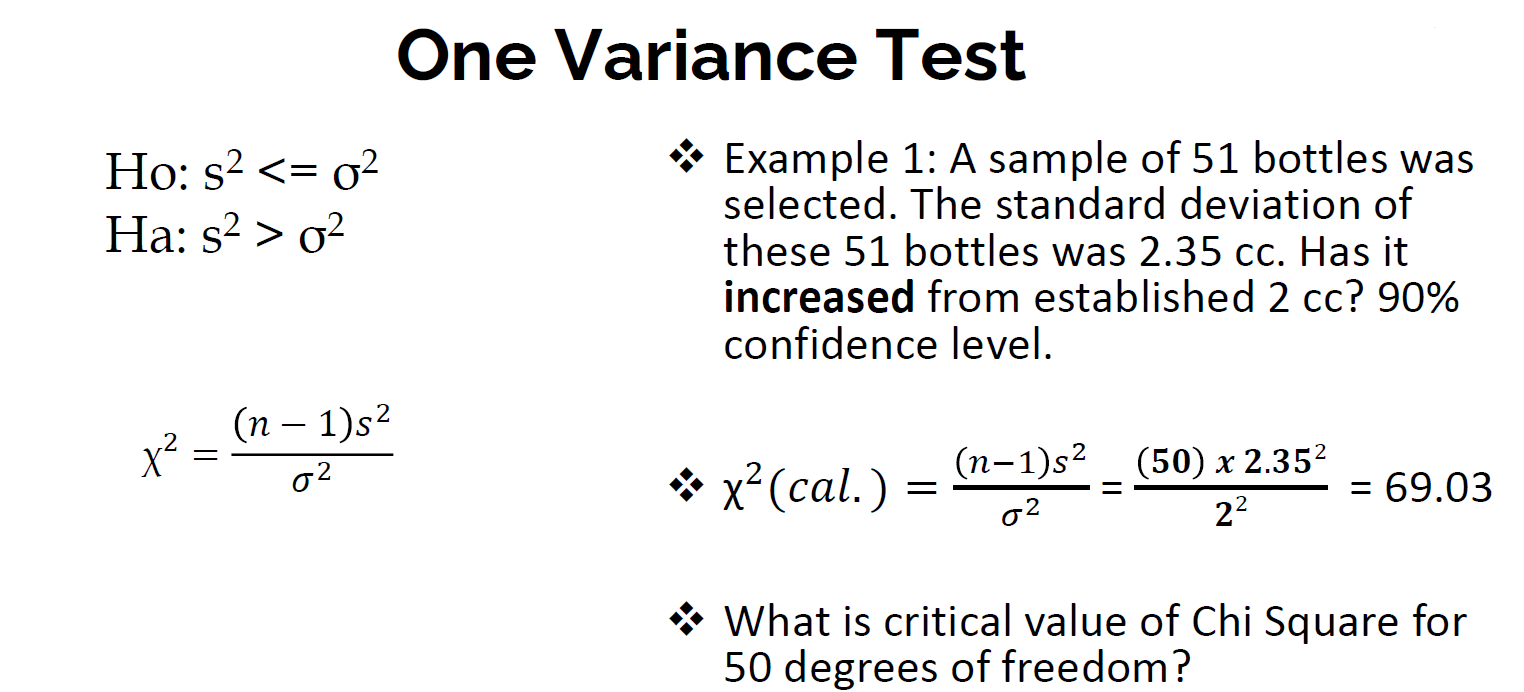

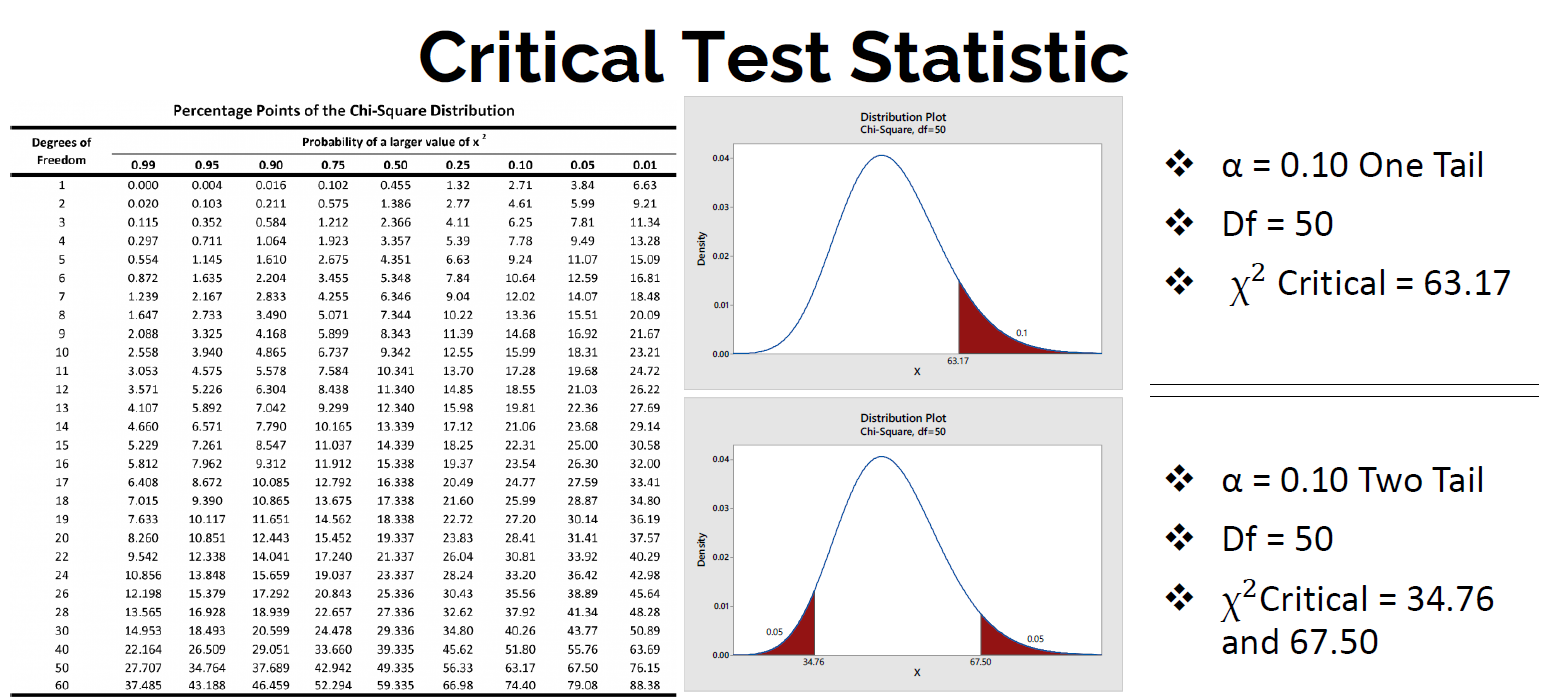

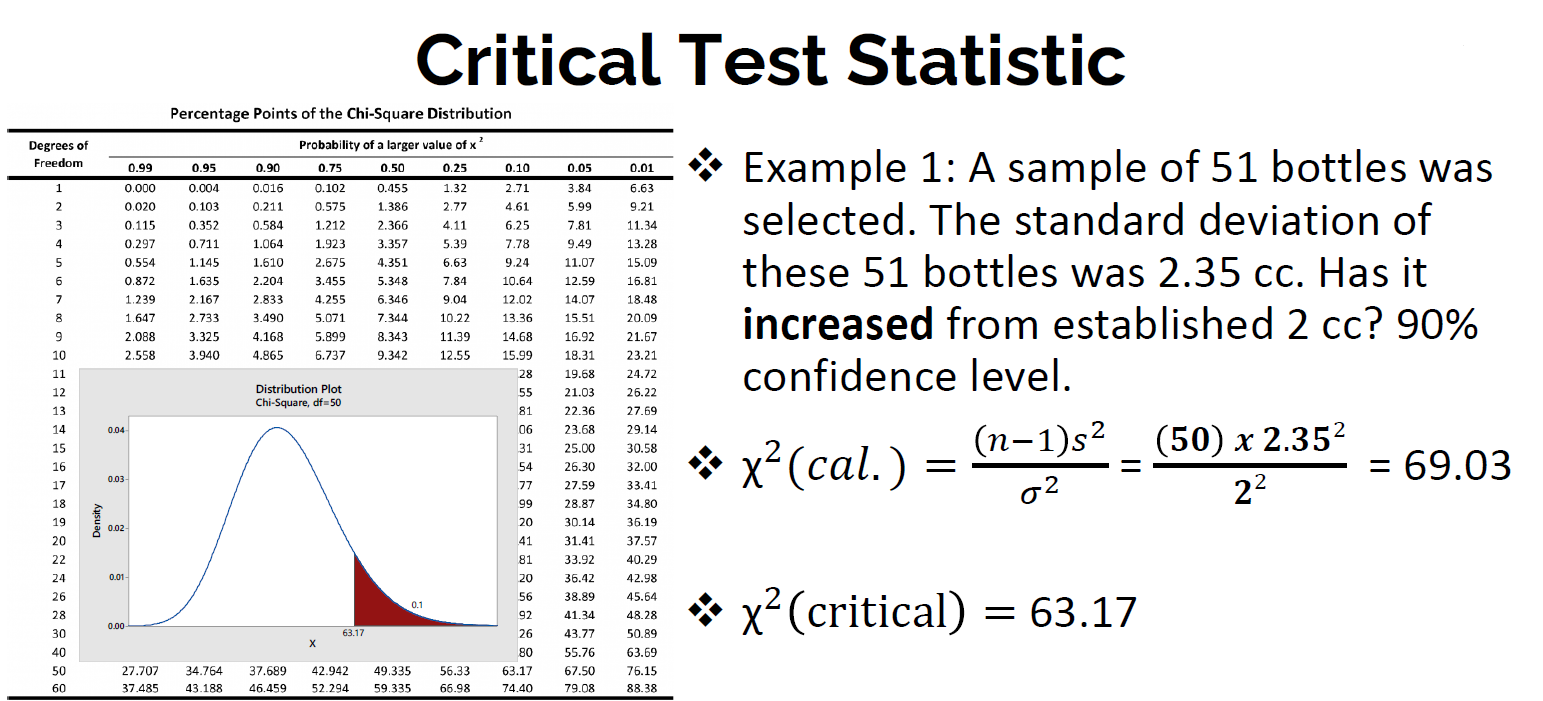

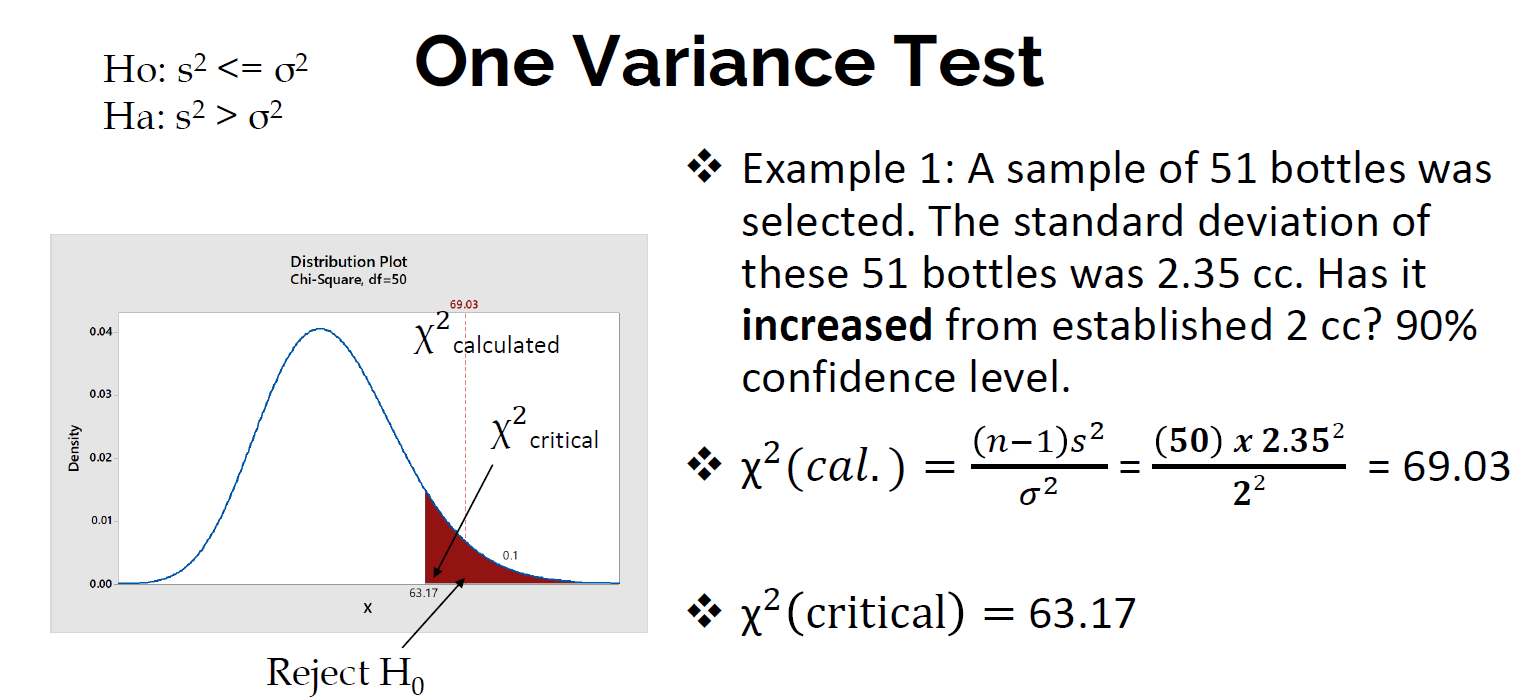

### Example 2:

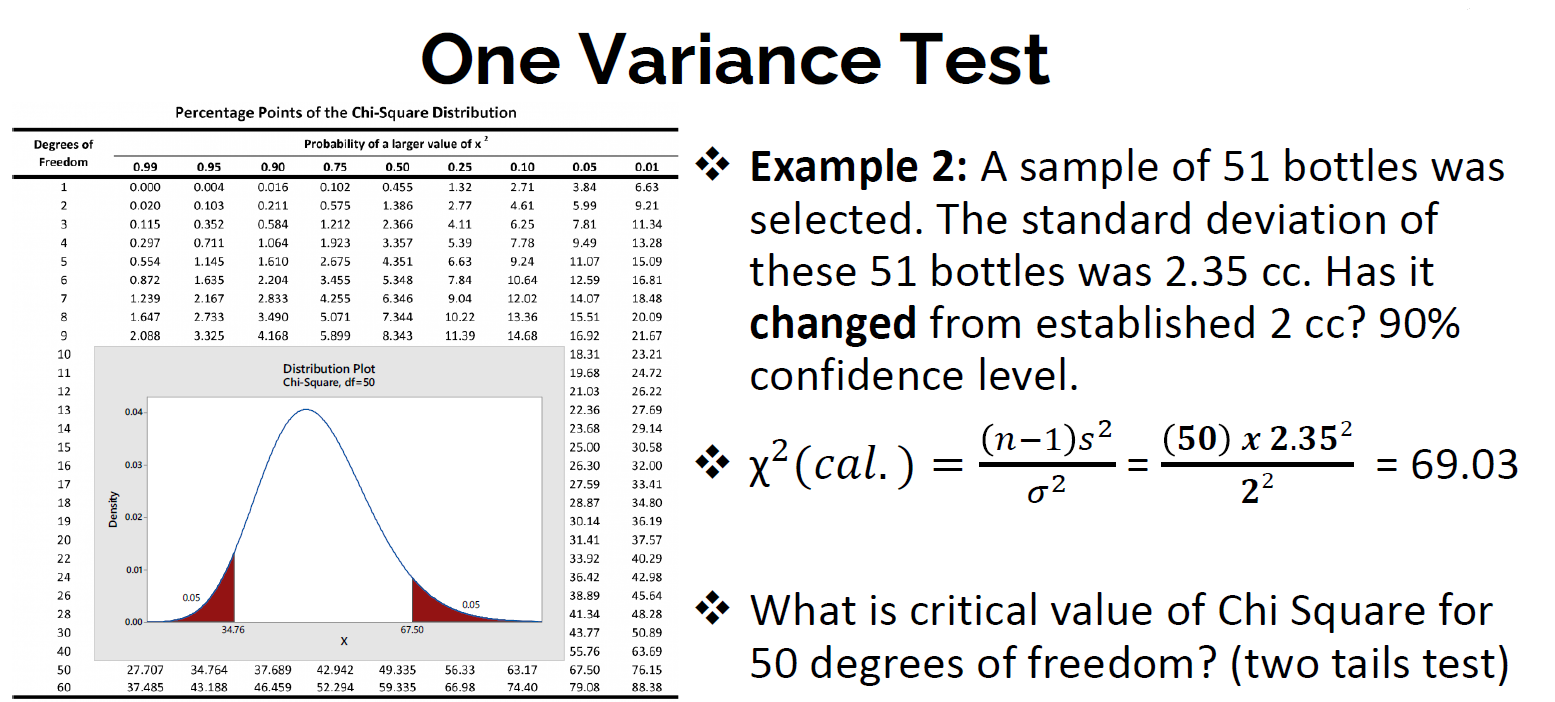

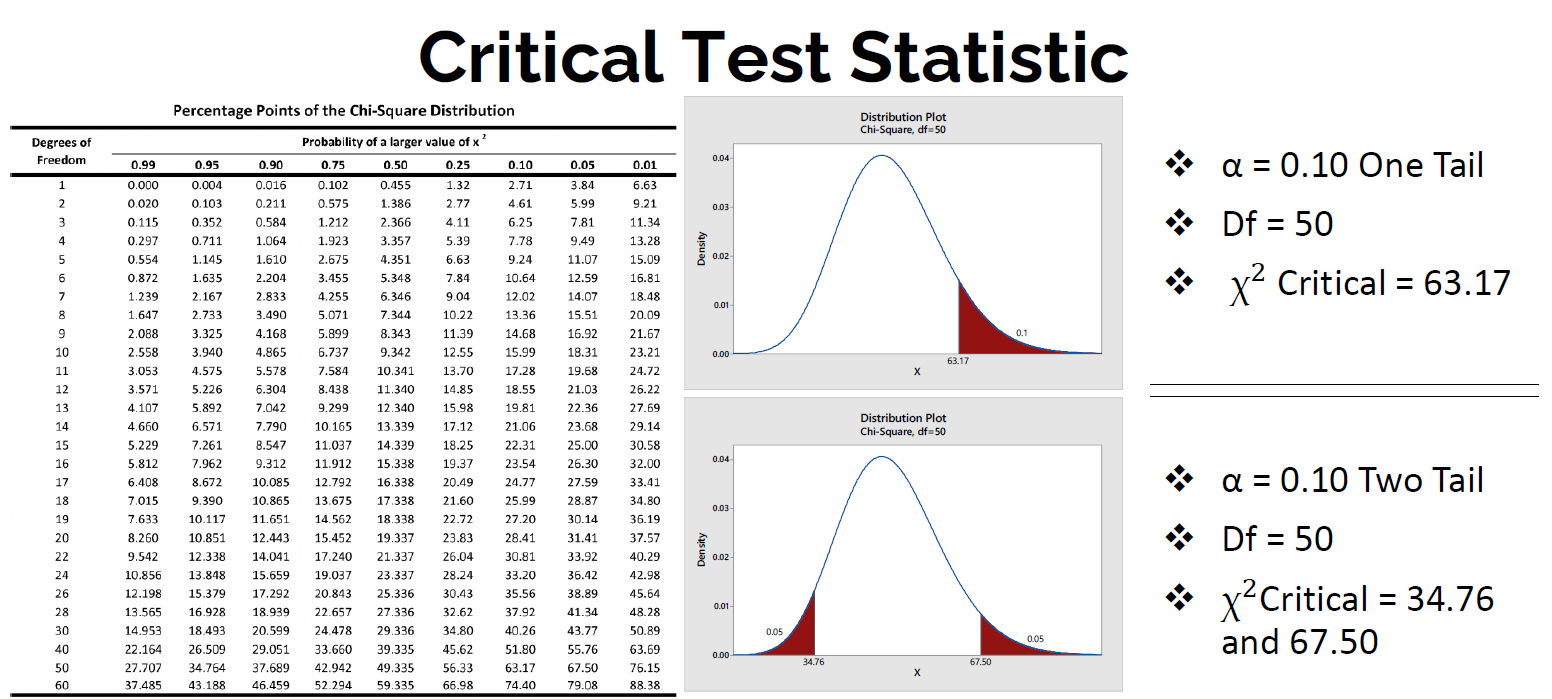

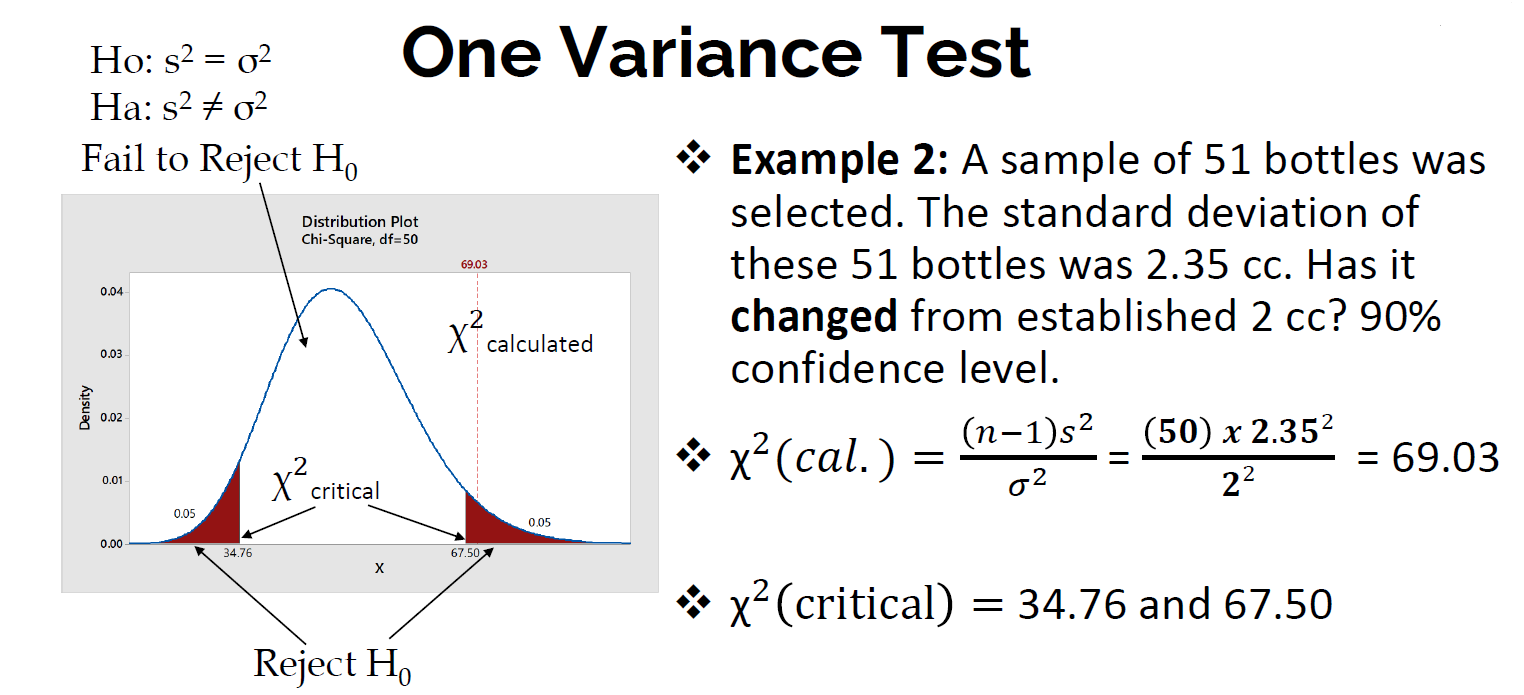

### One Variance Test Using Python:

#### Plotting Chi-Square Distribution

In [34]:
# X-Axis:

x_ax = np.linspace(0, 100, 101)
x_ax

array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
        11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,
        22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,
        33.,  34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,
        44.,  45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,
        55.,  56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,
        66.,  67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,
        77.,  78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,
        88.,  89.,  90.,  91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,
        99., 100.])

In [38]:
# Y-Axis:

y_ax = chi2.pdf(x= x_ax, df= 5)

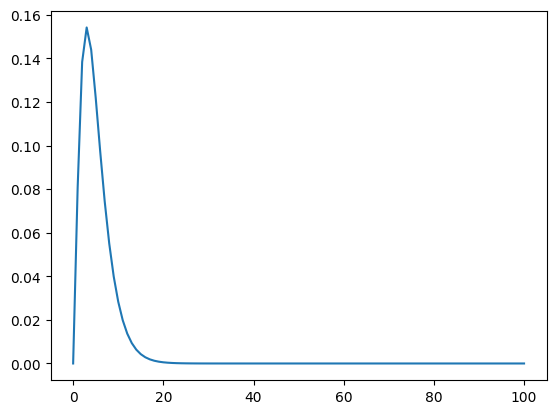

In [39]:
sns.lineplot(x= x_ax, y= y_ax)
plt.show()

In [40]:
# Y-Axis:

y_ax = chi2.pdf(x= x_ax, df= 50)

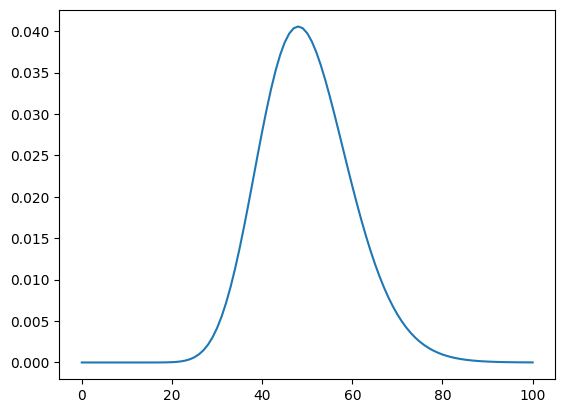

In [41]:
sns.lineplot(x= x_ax, y= y_ax)
plt.show()

##### Example 1: A sample of 51 bottles was selected. The standard deviation of these 51 bottles was 2.35 cc. Has it increased from the established 2cc? 90% confidence level.

H0 : s^2 <= sigma^2

Ha : s^2 > sigma^2

alpha = 0.1

Chi_sq_cal = (n-1)s^2 / sigma^2

In [42]:
chi_sq_calculated = (51-1) * 2.35**2 / 2**2
print(chi_sq_calculated)

69.03125000000001


In [43]:
chi2.isf(q= 0.1, df= 50)

63.167121005726315

Calculated Chi2 > Critical Chi2

**We Can Reject The Null Hypothesis**

##### Example 2: A sample of 51 bottles was selected. The standard deviation of these 51 bottles was 2.35 cc. Has it changed from the established 2cc? 90% confidence level.

H0 : s^2 = sigma^2

Ha : s^2 != sigma^2

alpha = 0.1

Chi_sq_cal = (n-1)s^2 / sigma^2

In [44]:
chi_sq_calculated = (51-1) * 2.35**2 / 2 ** 2
print(chi_sq_calculated)

69.03125000000001


In [45]:
chi2.isf(0.05, df= 50)

67.5048065495412

Calculated Chi2 > Critical Chi2

**We Can Reject The Null Hypothesis**